# `process(StateChange)` — Inducing Dyslexia in Qwen2.5-VL

Concrete demonstration of the brain-score `state_change_fn` mechanism. The shape of this notebook mirrors what a benchmark looks like at scale — replace `test_imgs` / `loc_imgs` with the full `Yeatman2021-lexical_decision-image` stimulus set and the rest stays unchanged.

Pattern: localize → score baseline → lesion via `process(StateChange(...))` → score lesioned → `reset()` → score restored.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

import brainscore
import brainscore_vision  # registers Qwen2.5-VL
from brainscore_core.model_interface import StateChange, Selection, Perturbation
from brainscore.perturbation import build_pytorch_ablation_fn


# --- helpers, not brain-score related ---
def render(word, size=224, font_size=56):
    img = Image.new('RGB', (size, size), 'white')
    for p in ('/System/Library/Fonts/Helvetica.ttc',
              '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf'):
        try: font = ImageFont.truetype(p, font_size); break
        except OSError: pass
    else: font = ImageFont.load_default()
    ImageDraw.Draw(img).text((size//2, size//2), word, fill='black',
                              anchor='mm', font=font)
    return img

def resolve(model, path):
    """Walk a dotted path on a torch module."""
    for p in path.split('.'):
        model = model[int(p)] if p.isdigit() else getattr(model, p)
    return model


/Users/kartik/Brain-Score Unified/core/brainscore_core/metrics/__init__.py:16: FutureWarning: xarray subclass Score should explicitly define __slots__
  class Score(DataAssembly):


## 1. Stimuli

In [2]:
TEST_REAL    = ['apple', 'school', 'ocean']
TEST_PSEUDO  = ['blapt', 'pringol', 'mishel']
LOC_REAL     = ['mountain','forest','sunset','tiger','doctor','rocket']
LOC_PSEUDO   = ['plapp','snorel','graspol','mendrel','flarbon','tronkel']

test_imgs   = [render(w) for w in TEST_REAL + TEST_PSEUDO]
test_truth  = ['real']*len(TEST_REAL) + ['pseudo']*len(TEST_PSEUDO)
loc_real    = [render(w) for w in LOC_REAL]
loc_pseudo  = [render(w) for w in LOC_PSEUDO]


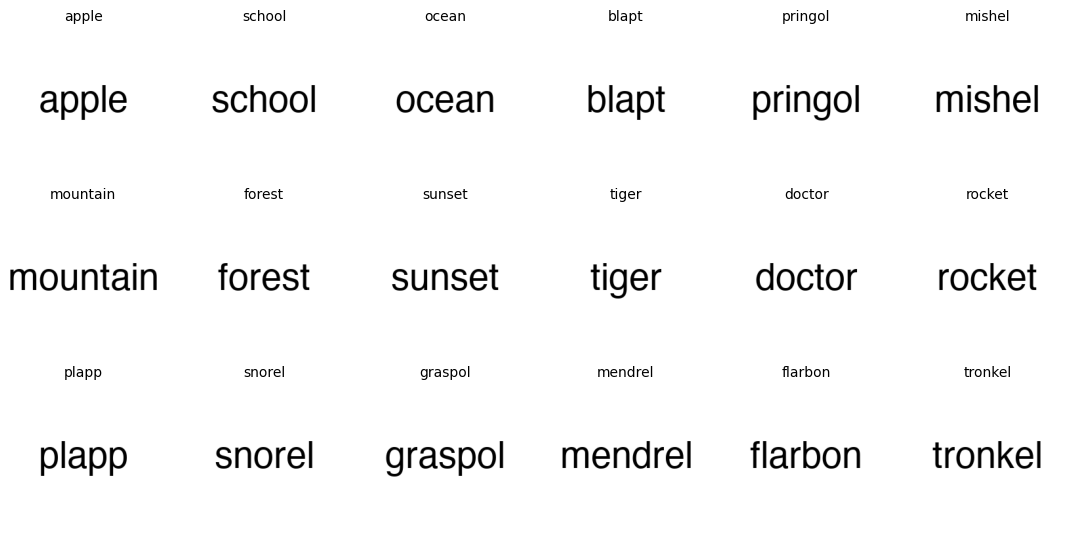

In [3]:
fig, axes = plt.subplots(3, 6, figsize=(11, 5.5))
for ax, img, w in zip(axes[0], test_imgs, TEST_REAL + TEST_PSEUDO):
    ax.imshow(img); ax.axis('off'); ax.set_title(w, fontsize=10)
for ax, img, w in zip(axes[1], loc_real, LOC_REAL):
    ax.imshow(img); ax.axis('off'); ax.set_title(w, fontsize=10)
for ax, img, w in zip(axes[2], loc_pseudo, LOC_PSEUDO):
    ax.imshow(img); ax.axis('off'); ax.set_title(w, fontsize=10)
for ax, lbl in zip(axes[:, 0], ['Test', 'Localizer\n(real)', 'Localizer\n(pseudo)']):
    ax.set_ylabel(lbl, rotation=0, ha='right', va='center', fontsize=11)
plt.tight_layout(); plt.show()


## 2. Load model + attach `state_change_fn`

In [4]:
bs_model = brainscore.load_model('qwen2.5-vl-3b')
bs_model._state_change_fn = build_pytorch_ablation_fn(bs_model._model)

device = ('mps' if torch.backends.mps.is_available()
          else 'cuda' if torch.cuda.is_available() else 'cpu')
qwen = bs_model._model.to(device).eval()
processor = bs_model._preprocessors['vision']._processor


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

## 3. Proto-benchmark — localizer and scoring functions

Three functions that approximate what a `brain-score` benchmark exposes at scale:
- `localize(real_imgs, pseudo_imgs, layer, k)` — identify the `k` most word-selective units at `layer`.
- `classify(image)` — single-stimulus lexical decision via Qwen's generation.
- `score(images, labels)` — accuracy on a stimulus set. Same signature shape as `Benchmark.__call__(model)`.

Replacing `test_imgs / test_truth` with the full `Yeatman2021-lexical_decision-image` stimulus set is the only change needed to run this experiment at scale.

In [5]:
PROMPT_LOC  = 'What word is shown in this image?'
PROMPT_TEST = 'Is the word in this image a real English word? '\
              'Answer with exactly one of: real, pseudo.'

def _generate(image, prompt, max_new_tokens):
    msg = [{'role': 'user', 'content': [
        {'type': 'image', 'image': image},
        {'type': 'text',  'text': prompt}]}]
    text = processor.apply_chat_template(msg, tokenize=False,
                                          add_generation_prompt=True)
    inputs = processor(text=[text], images=[image],
                       return_tensors='pt').to(device)
    with torch.no_grad():
        out = qwen.generate(**inputs, max_new_tokens=max_new_tokens,
                            do_sample=False)
    return processor.tokenizer.decode(
        out[0, inputs['input_ids'].shape[1]:],
        skip_special_tokens=True).strip().lower()

def classify(image):
    response = _generate(image, PROMPT_TEST, max_new_tokens=4)
    return 'real' if 'real' in response else (
           'pseudo' if 'pseudo' in response else 'unparseable')

def score(images, labels):
    """Returns (accuracy, list_of_predictions). Same shape as a
    brain-score Score that carries per-trial predictions in attrs."""
    preds = [classify(im) for im in images]
    acc = float(np.mean([p == l for p, l in zip(preds, labels)]))
    return acc, preds

def localize(real_imgs, pseudo_imgs, layer_path, k):
    layer = resolve(qwen, layer_path)
    captured = []
    def hook(_m, _i, output):
        h = output[0] if isinstance(output, tuple) else output
        captured.append(h.detach().to('cpu', dtype=torch.float32)
                         .mean(dim=1).squeeze(0).numpy())
    handle = layer.register_forward_hook(hook)
    for img in real_imgs + pseudo_imgs:
        _generate(img, PROMPT_LOC, max_new_tokens=1)
    handle.remove()
    real_act   = np.stack(captured[:len(real_imgs)])
    pseudo_act = np.stack(captured[len(real_imgs):])
    selectivity = real_act.mean(0) - pseudo_act.mean(0)
    return np.argsort(selectivity)[-k:].tolist(), selectivity


## 4. Run the experiment

Three brain-score calls bracket two scoring passes:

In [6]:
LAYER = 'model.language_model.layers.34'
TOP_K = 1500

word_units, selectivity = localize(loc_real, loc_pseudo, LAYER, TOP_K)

baseline, base_preds = score(test_imgs, test_truth)

applied = bs_model.process(StateChange(
    kind='ablation',
    target=Selection(layer=LAYER, indices=word_units),
    perturbation=Perturbation(kind='zero'),
))
lesioned, les_preds = score(test_imgs, test_truth)

bs_model.reset()
restored, res_preds = score(test_imgs, test_truth)

print(f'baseline={baseline:.2f}  lesioned={lesioned:.2f}  restored={restored:.2f}')


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


baseline=1.00  lesioned=0.17  restored=1.00


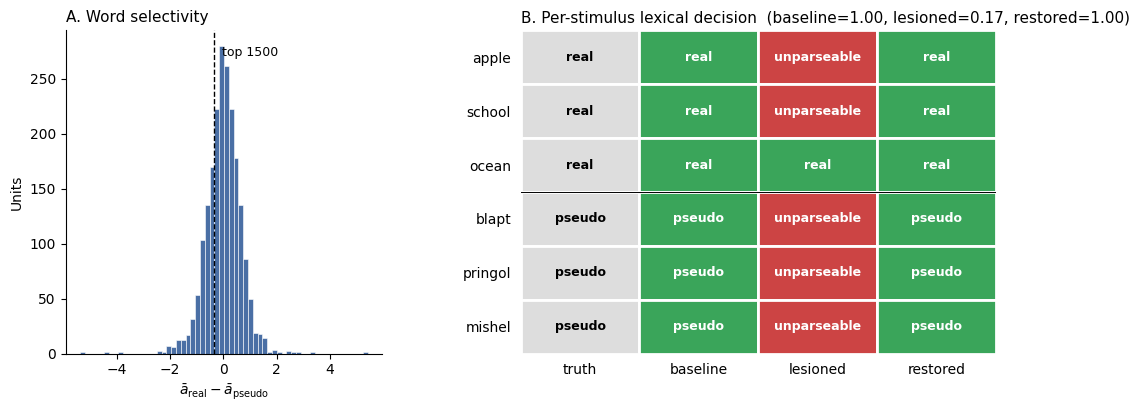

In [7]:
fig = plt.figure(figsize=(12, 4.2))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 3], wspace=0.35)
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])

# Panel A — selectivity histogram
thr = selectivity[word_units].min()
ax_a.hist(selectivity, bins=60, color='#4a6fa5',
          edgecolor='white', linewidth=0.4)
ax_a.axvline(thr, color='black', lw=1, ls='--')
ax_a.text(thr, ax_a.get_ylim()[1] * 0.92, f'  top {TOP_K}',
          ha='left', fontsize=9)
ax_a.set_xlabel(r'$\bar{a}_\mathrm{real} - \bar{a}_\mathrm{pseudo}$')
ax_a.set_ylabel('Units')
ax_a.set_title('A. Word selectivity', loc='left', fontsize=11)

# Panel B — per-stimulus prediction matrix
stims = TEST_REAL + TEST_PSEUDO
cols  = [('truth', test_truth),
         ('baseline', base_preds),
         ('lesioned', les_preds),
         ('restored', res_preds)]
for ci, (name, preds) in enumerate(cols):
    for ri, pred in enumerate(preds):
        if name == 'truth':
            color = '#dddddd'
        else:
            color = '#3aa55a' if pred == test_truth[ri] else '#cc4444'
        ax_b.add_patch(plt.Rectangle((ci, ri), 1, 1,
                                     facecolor=color, edgecolor='white', lw=2))
        ax_b.text(ci + 0.5, ri + 0.5, pred, ha='center', va='center',
                  color='black' if name == 'truth' else 'white',
                  fontsize=9, fontweight='bold')
ax_b.set_xlim(0, len(cols))
ax_b.set_ylim(0, len(stims))
ax_b.invert_yaxis()
ax_b.set_xticks(np.arange(len(cols)) + 0.5)
ax_b.set_xticklabels([c[0] for c in cols], fontsize=10)
ax_b.set_yticks(np.arange(len(stims)) + 0.5)
ax_b.set_yticklabels(stims, fontsize=10)
ax_b.tick_params(left=False, bottom=False)
ax_b.axhline(len(TEST_REAL), color='black', lw=0.7)
ax_b.set_title('B. Per-stimulus lexical decision  '
               f'(baseline={baseline:.2f}, '
               f'lesioned={lesioned:.2f}, '
               f'restored={restored:.2f})',
               loc='left', fontsize=11)

for ax in (ax_a, ax_b):
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'): ax_b.spines[sp].set_visible(False)
plt.show()


## Scaling to the published benchmark

Replace the four lines defining `test_imgs / test_truth / loc_real / loc_pseudo` with:

```python
benchmark = brainscore.load_benchmark('Yeatman2021-lexical_decision-image')
test_stim, train_stim = benchmark._test_stimuli, benchmark._train_stimuli
test_imgs   = [Image.open(p) for p in test_stim['image_file_name']]
test_truth  = list(test_stim['image_label'])
loc_real    = [Image.open(p) for p, l in zip(train_stim['image_file_name'],
                                              train_stim['image_label']) if l == 'real']
loc_pseudo  = [Image.open(p) for p, l in zip(train_stim['image_file_name'],
                                              train_stim['image_label']) if l == 'pseudo']
```

Everything else stays. Estimated wall-clock for 100 test + 400 localizer on Mac MPS: ~35 min. On EC2 g5.4xlarge: ~10 min.